In [1]:
import numpy as np
import pandas as pd

from skfp.preprocessing import MolFromSmilesTransformer
from skfp.fingerprints import RDKit2DDescriptorsFingerprint

/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('alkynes_smi.csv')
df.head()

,SMILES,code_name
0,C#CC(=O)C(C)C,1
1,C#CC(=O)C(OCC)OCC,2
2,C#CC(=O)CC,3
3,C#CC(=O)CCC,4
4,C#CC(=O)CCc1ccccc1,5


In [3]:
smiles_list = df['SMILES'].tolist()

mol_trans = MolFromSmilesTransformer(verbose=1)
mols = mol_trans.fit_transform(smiles_list)

rdkit_fp = RDKit2DDescriptorsFingerprint(verbose=1)
x = rdkit_fp.fit_transform(mols)

100%|██████████| 1312/1312 [00:04<00:00, 295.55it/s]


In [4]:
X_df = pd.DataFrame(x, index=smiles_list, columns=rdkit_fp.get_feature_names_out())
X_df

,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,qed
C#CC(=O)C(C)C,3.640686,105.838654,5.861807,4.562949,4.562949,3.180739,2.186175,2.186175,1.663289,1.663289,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.349047
C#CC(=O)C(OCC)OCC,3.891299,151.210327,8.690234,6.793659,6.793659,5.256749,3.494443,3.494443,1.751199,1.751199,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.331758
C#CC(=O)CC,3.328394,86.601791,4.991564,3.692705,3.692705,2.808060,1.803459,1.803459,0.921067,0.921067,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.334147
C#CC(=O)CCC,3.235744,97.237869,5.698670,4.399812,4.399812,3.308060,2.303459,2.303459,1.317514,1.317514,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.369816
C#CC(=O)CCc1ccccc1,2.450791,292.530182,8.811555,6.786563,6.786563,5.825698,3.860590,3.860590,2.553113,2.553113,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.484130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OCCC#Cc1ccccn1,2.592355,257.886383,7.941311,6.118042,6.118042,5.431852,3.440262,3.440262,1.990361,1.990361,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.596301
OCCC#Cc1cccnc1,2.592355,257.886383,7.941311,6.118042,6.118042,5.431852,3.430196,3.430196,2.017084,2.017084,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.596301
OCCC#Cc1ccncc1,2.592355,257.886383,7.941311,6.118042,6.118042,5.431852,3.430196,3.430196,2.011272,2.011272,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.596301
OCc1ccc(C#CC(F)(F)F)cc1,2.818741,353.683990,10.604448,7.097615,7.097615,6.510150,3.808095,3.808095,2.602796,2.602796,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.688010


In [5]:
from sklearn.preprocessing import scale

# standardize
X_df = pd.DataFrame(scale(X_df), index=X_df.index, columns=X_df.columns)

# drop zero-variance features
zero_std_cols = X_df.columns[X_df.std() == 0]
X_df = X_df[X_df.columns.difference(zero_std_cols)]

print(f"Dropping {len(zero_std_cols)} features {zero_std_cols}")

Dropping 44 features Index(['EState_VSA11', 'NumRadicalElectrons', 'SMR_VSA2', 'SMR_VSA8',
       'SlogP_VSA9', 'fr_Ar_COO', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_SH',
       'fr_alkyl_carbamate', 'fr_allylic_oxid', 'fr_amidine', 'fr_azide',
       'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo',
       'fr_dihydropyridine', 'fr_epoxide', 'fr_guanido', 'fr_hdrzine',
       'fr_hdrzone', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitrile',
       'fr_nitro', 'fr_nitro_arom', 'fr_nitro_arom_nonortho', 'fr_nitroso',
       'fr_oxime', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd',
       'fr_quatN', 'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_tetrazole',
       'fr_thiazole', 'fr_thiocyan', 'fr_thiophene', 'fr_urea'],
      dtype='object')


/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:265: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/sklearn/preprocessing/_data.py:284: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


In [6]:
# drop highly correlated features
df_corr = X_df.corr().abs()
upper = df_corr.where(np.triu(np.ones(df_corr.shape),k=1).astype(np.bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]
X_df = X_df.drop(to_drop, axis=1)

print(f"Dropping {len(to_drop)} features {to_drop}")


Dropping 61 features ['Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'ExactMolWt', 'FpDensityMorgan2', 'FpDensityMorgan3', 'HallKierAlpha', 'HeavyAtomCount', 'HeavyAtomMolWt', 'Ipc', 'Kappa1', 'Kappa3', 'LabuteASA', 'MaxEStateIndex', 'MinAbsPartialCharge', 'MinEStateIndex', 'MinPartialCharge', 'MolMR', 'MolWt', 'NumAromaticRings', 'NumHAcceptors', 'NumHDonors', 'NumRotatableBonds', 'NumSaturatedCarbocycles', 'NumSaturatedRings', 'NumValenceElectrons', 'RingCount', 'SMR_VSA5', 'SMR_VSA7', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA5', 'SlogP_VSA6', 'TPSA', 'VSA_EState1', 'VSA_EState10', 'VSA_EState6', 'fr_Al_OH', 'fr_Al_OH_noTert', 'fr_Ar_N', 'fr_COO', 'fr_COO2', 'fr_C_O', 'fr_C_O_noCOO', 'fr_NH0', 'fr_NH2', 'fr_Nhpyrrole', 'fr_alkyl_halide', 'fr_benzene', 'fr_ketone_Topliss', 'fr_phenol', 'fr_phenol_noOrthoHbond']


In [10]:
X_df

,BalabanJ,BertzCT,Chi0,EState_VSA1,EState_VSA10,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,...,fr_morpholine,fr_oxazole,fr_para_hydroxylation,fr_piperdine,fr_piperzine,fr_priamide,fr_pyridine,fr_term_acetylene,fr_unbrch_alkane,qed
C#CC(=O)C(C)C,1.841079,-1.609714,-1.706558,-0.546859,0.274420,1.041177,-1.068639,-0.921893,-0.703089,0.673587,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,-0.441564,0.483987,-0.257592,-1.595341
C#CC(=O)C(OCC)OCC,2.489311,-1.202760,0.060926,2.159833,0.274420,-0.964898,0.928777,-0.921893,-0.703089,0.673587,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,-0.441564,0.483987,-0.257592,-1.745927
C#CC(=O)CC,1.033312,-1.782256,-2.250374,-0.546859,0.274420,0.026596,-0.098056,-0.921893,-0.703089,-0.103981,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,-0.441564,0.483987,-0.257592,-1.725120
C#CC(=O)CCC,0.793666,-1.686858,-1.808503,-0.546859,0.274420,0.026596,-0.098056,-0.077039,-0.703089,-0.881549,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,-0.441564,0.483987,-0.257592,-1.414433
C#CC(=O)CCc1ccccc1,-1.236680,0.064788,0.136740,-0.546859,0.274420,0.026596,-0.098056,0.655002,-0.703089,-0.881549,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,-0.441564,0.483987,-0.257592,-0.418734
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OCCC#Cc1ccccn1,-0.870514,-0.245945,-0.407076,-0.546859,-0.896153,0.167803,-0.098056,-0.172684,-0.703089,-0.185615,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,2.215925,-2.066172,-0.257592,0.558300
OCCC#Cc1cccnc1,-0.870514,-0.245945,-0.407076,-0.546859,-0.896153,0.167803,-0.098056,-0.189852,-0.703089,0.510320,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,2.215925,-2.066172,-0.257592,0.558300
OCCC#Cc1ccncc1,-0.870514,-0.245945,-0.407076,-0.546859,-0.896153,0.167803,-0.098056,-0.189852,-0.703089,0.510320,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,2.215925,-2.066172,-0.257592,0.558300
OCc1ccc(C#CC(F)(F)F)cc1,-0.284946,0.613298,1.257119,0.837798,2.319571,1.121615,-0.227658,-0.142880,2.450315,-0.881549,...,-0.107542,-0.047873,-0.240438,-0.083109,-0.078326,-0.087638,-0.441564,-2.066172,-0.257592,1.357111


In [7]:
from sklearn.decomposition import PCA
from umap import UMAP

dims = [50, 20, 15, 10, 5, 2]

dfs = {}

# UMAP section
n_neigh = np.int_(np.sqrt(X_df.shape[1]))
for dim in dims:
    key = f"umap{dim}"
    dfs[key] = pd.DataFrame(UMAP(
        n_components=dim, n_neighbors=n_neigh,random_state=0
    ).fit_transform(X_df), index=X_df.index)

# PCA section
pc = pd.DataFrame(PCA(n_components=None).fit_transform(X_df), index=X_df.index)
for dim in dims:
    key = f"pc{dim}"
    dfs[key] = pc.iloc[:, :dim]

/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/miniconda3/envs/chem/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/kimariyb/env/minico

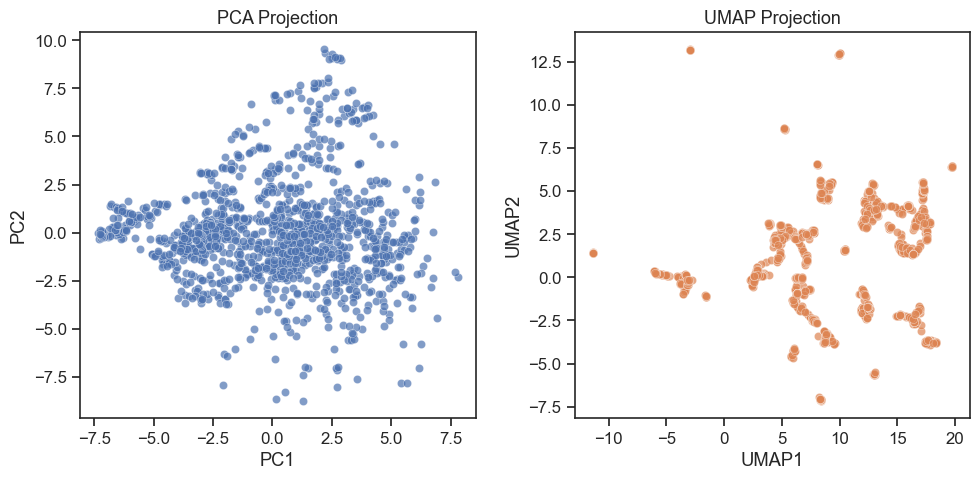

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", context="notebook", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.2

# =========================
# Data
# =========================
dfs['pc2'].columns = ['PC1', 'PC2']
dfs['umap2'].columns = ['UMAP1', 'UMAP2']

# =========================
# Figure
# =========================
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# PCA
sns.scatterplot(
    data=dfs['pc2'],
    x='PC1',
    y='PC2',
    s=35,
    alpha=0.7,
    color='#4C72B0',
    edgecolor='white',
    linewidth=0.3,
    ax=ax[0]
)

ax[0].set_title("PCA Projection", fontsize=13)
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

# UMAP
sns.scatterplot(
    data=dfs['umap2'],
    x='UMAP1',
    y='UMAP2',
    s=35,
    alpha=0.7,
    color='#DD8452',
    edgecolor='white',
    linewidth=0.3,
    ax=ax[1]
)

ax[1].set_title("UMAP Projection", fontsize=13)
ax[1].set_xlabel("UMAP1")
ax[1].set_ylabel("UMAP2")

# =========================
# Style polishing
# =========================

plt.tight_layout()
plt.subplots_adjust(wspace=0.25)
fig.savefig("../fig/rdkit_1.svg", dpi=330)
fig.savefig("../fig/rdkit_1.pdf", dpi=330)
plt.show()

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, fclusterdata
from sklearn.metrics import silhouette_score

# Define the numbeor of clusters to study
N_CLS_list = list(range(5, 41))
def silhouette_scores_hierarchical(data, n_cls_list):
    """helper function to compute a silhouette score for hierarchical cluster ing using Ward linkage"""
    z = linkage(data, method='ward')
    result = pd.Series(index=n_cls_list, dtype=float)
    for n_cls in n_cls_list:
        cls = fcluster(z, n_cls, criterion='maxclust')
        result.loc[n_cls] = silhouette_score(data, cls)
    return result

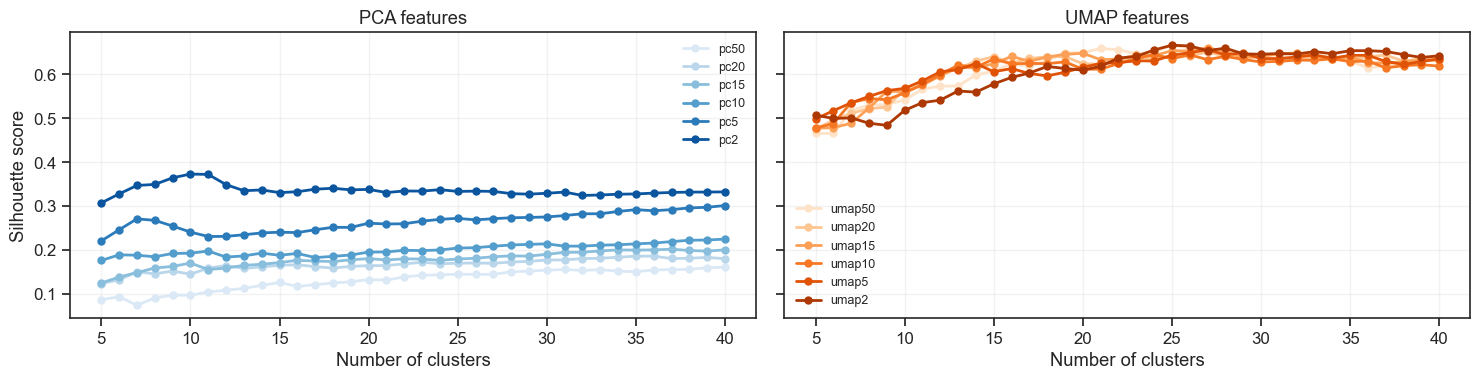

In [11]:
silh_scores = pd.DataFrame(index=N_CLS_list)

for key, value in dfs.items():
    silh_scores[key] = silhouette_scores_hierarchical(value, N_CLS_list)

# 分组
pca_cols = silh_scores.columns[silh_scores.columns.str.startswith("pc")]
umap_cols = silh_scores.columns[silh_scores.columns.str.startswith("umap")]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

pca_palette = sns.color_palette("Blues", len(pca_cols))
umap_palette = sns.color_palette("Oranges", len(umap_cols))

# PCA
for i, col in enumerate(pca_cols):
    ax[0].plot(
        silh_scores.index,
        silh_scores[col],
        marker='o',
        linewidth=2,
        markersize=5,
        color=pca_palette[i],
        label=col
    )

ax[0].set_title("PCA features")
ax[0].set_xlabel("Number of clusters")
ax[0].set_ylabel("Silhouette score")
ax[0].legend(frameon=False, fontsize=9)

# UMAP
for i, col in enumerate(umap_cols):
    ax[1].plot(
        silh_scores.index,
        silh_scores[col],
        marker='o',
        linewidth=2,
        markersize=5,
        color=umap_palette[i],
        label=col
    )

ax[1].set_title("UMAP features")
ax[1].set_xlabel("Number of clusters")
ax[1].legend(frameon=False, fontsize=9)

# Style
for a in ax:
    a.grid(alpha=0.25)

plt.tight_layout()
fig.savefig("../fig/rdkit_2.svg", dpi=330)
fig.savefig("../fig/rdkit_2.pdf", dpi=330)
plt.show()